# Part 2 — Multimodal SAE Detection

**Models:** MedGemma 1.5-4B (VLM) + MedSigLIP-448 (vision encoder) + HeAR (audio)  
**Task:** Detect adverse events from patient photographs and cough audio  
**Part A:** Visual AE detection — 21 categories (normal + 7 AE types × 3 CTCAE grades)  
**Part B:** Cough detection — 2-stage HeAR classifier (dry / wet / none)

---

This notebook is part of the **MedGemma Clinical Trial Engine** pipeline:

```
NB1  Anti-Hallucination ──── RLFR fine-tuning for reliable medical text (MedGemma)
NB2  SAE Detection ────────── MedGemma 1.5 + MedSigLIP + HeAR (image + audio → AE)
NB3  Clinical Trial Sim ──── Rule set generation + hazard-based daily simulation
NB4  Voice Call App ────────── MedGemma 4B virtual nurse (multi-turn dialogue)
NB5  SAE Report Gen ────────── CRF data → MedWatch 3500A pharmacovigilance reports
```

---

# Part A — Visual AE Detection

**Models:** MedGemma 1.5-4B (Zeroshot + Finetuned) + MedSigLIP-448 (Zeroshot + Finetuned)

In [1]:
# ── Install dependencies ──
!pip install -q torch transformers accelerate Pillow matplotlib numpy huggingface-hub

# ── Install this project (for src.* imports) ──
!pip install -q -e ..

# ── HuggingFace login ──
# Required for gated Google models. Get your token at: https://huggingface.co/settings/tokens
# Also request access to:
#   - https://huggingface.co/google/medgemma-1.5-4b-it
#   - https://huggingface.co/google/medsiglip-448
import os
from huggingface_hub import login

HF_TOKEN = ""  # <-- paste your HuggingFace token here

if HF_TOKEN:
    login(token=HF_TOKEN)
elif os.environ.get("HF_TOKEN"):
    login(token=os.environ["HF_TOKEN"])
else:
    login()

ERROR: file:///home/samuel does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [2]:
import json, re, time, os, sys
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from transformers import (
    AutoModelForImageTextToText, AutoProcessor,
    AutoModel, AutoImageProcessor,
)
from IPython.display import display, HTML
from huggingface_hub import snapshot_download

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.multimodal.config import build_ctcae_table_text, get_config, SIGLIP_CLASSES

# ── Download data & models from HuggingFace ──
DATA_DIR = Path(snapshot_download("AlphaRaven/clinical-trial-engine-data", repo_type="dataset"))

IMAGE_DIR       = DATA_DIR / "ae_images"
SIGLIP_FT_DIR   = DATA_DIR / "siglip_ft_head"
GEMMA_FT_MODEL_ID = "AlphaRaven/medgemma-ae-detection"
GPU_ID = 0   # ← change to your GPU index

cfg = get_config()
CLASSES = SIGLIP_CLASSES

print(f"Images:    {IMAGE_DIR}")
print(f"Gemma FT:  {GEMMA_FT_MODEL_ID}")
print(f"SigLIP FT: {SIGLIP_FT_DIR}")
print(f"GPU:       {GPU_ID}")
print(f"Classes:   {len(CLASSES)}")

2026-02-25 04:20:25.202554: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/home/samuel/miniforge3/envs/medgemma/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Fetching 247 files:   0%|          | 0/247 [00:00<?, ?it/s]

Images:    /home/samuel/.cache/huggingface/hub/datasets--AlphaRaven--clinical-trial-engine-data/snapshots/dc4526af83a4722707ed993fda2149b4c94b4bb7/ae_images
Gemma FT:  AlphaRaven/medgemma-ae-detection
SigLIP FT: /home/samuel/.cache/huggingface/hub/datasets--AlphaRaven--clinical-trial-engine-data/snapshots/dc4526af83a4722707ed993fda2149b4c94b4bb7/siglip_ft_head
GPU:       0
Classes:   21


## 2. Load Models

### Model A — MedGemma 1.5 4B (Zeroshot + Finetuned)
- **Zeroshot**: `google/medgemma-1.5-4b-it` (HF base)
- **Finetuned**: `medgemma_ae_detection_model` (AntiHallu + LoRA ep50 merged)

In [3]:
device = torch.device(f"cuda:{GPU_ID}")

print("Loading MedGemma processor ...")
gemma_processor = AutoProcessor.from_pretrained("google/medgemma-1.5-4b-it")

print("Loading MedGemma Zeroshot (HF base) ...")
gemma_zeroshot = AutoModelForImageTextToText.from_pretrained(
    "google/medgemma-1.5-4b-it",
    torch_dtype=torch.bfloat16, device_map={"": GPU_ID},
)
gemma_zeroshot.eval()
print(f"  Zeroshot: {sum(p.numel() for p in gemma_zeroshot.parameters())/1e9:.2f}B params")

print(f"Loading MedGemma Finetuned from {GEMMA_FT_MODEL_ID} ...")
gemma_finetuned = AutoModelForImageTextToText.from_pretrained(
    GEMMA_FT_MODEL_ID, torch_dtype=torch.bfloat16, device_map={"": GPU_ID},
)
gemma_finetuned.eval()
print(f"  Finetuned: {sum(p.numel() for p in gemma_finetuned.parameters())/1e9:.2f}B params")
print("MedGemma models loaded.")

Loading MedGemma processor ...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading MedGemma Zeroshot (HF base) ...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Zeroshot: 4.30B params
Loading MedGemma Finetuned from AlphaRaven/medgemma-ae-detection ...


  Finetuned: 4.30B params
MedGemma models loaded.


### Model B — MedSigLIP-448 (Zeroshot + Finetuned)
- **Zeroshot**: Text-Image contrastive matching (21 class text prompts)
- **Finetuned**: Frozen encoder + classification head (Linear Probe, ep27)

In [4]:
import torch.nn as nn

SIGLIP_MODEL_ID = "google/medsiglip-448"
SIGLIP_IMAGE_SIZE = 448
SIGLIP_EMBED_DIM = 1152

print("Loading MedSigLIP-448 ...")
try:
    siglip_processor = AutoProcessor.from_pretrained(SIGLIP_MODEL_ID)
    siglip_image_processor = AutoImageProcessor.from_pretrained(SIGLIP_MODEL_ID)
    siglip_model = AutoModel.from_pretrained(SIGLIP_MODEL_ID).to(device)
except OSError:
    print("  Online access failed, loading from local cache...")
    siglip_processor = AutoProcessor.from_pretrained(SIGLIP_MODEL_ID, local_files_only=True)
    siglip_image_processor = AutoImageProcessor.from_pretrained(SIGLIP_MODEL_ID, local_files_only=True)
    siglip_model = AutoModel.from_pretrained(SIGLIP_MODEL_ID, local_files_only=True).to(device)
siglip_model.eval()
for p in siglip_model.parameters():
    p.requires_grad = False
print(f"  SigLIP encoder: {sum(p.numel() for p in siglip_model.parameters())/1e6:.0f}M params")

# Zeroshot text prompts
CLASS_TEXT_PROMPTS = {
    "normal": "a clinical photograph of a normal patient face with no adverse events",
    "rash_maculopapular_g1": "a clinical photograph of a patient face with mild grade 1 maculopapular rash, faint pink macules",
    "rash_maculopapular_g2": "a clinical photograph of a patient face with moderate grade 2 maculopapular rash, widespread red papules",
    "rash_maculopapular_g3": "a clinical photograph of a patient face with severe grade 3 maculopapular rash, confluent erythematous lesions",
    "rash_acneiform_g1": "a clinical photograph of a patient face with mild grade 1 acneiform rash, scattered papules and pustules",
    "rash_acneiform_g2": "a clinical photograph of a patient face with moderate grade 2 acneiform rash, widespread acne-like eruption",
    "rash_acneiform_g3": "a clinical photograph of a patient face with severe grade 3 acneiform rash, confluent pustular lesions",
    "periorbital_edema_g1": "a clinical photograph of a patient face with mild grade 1 periorbital edema, slight puffiness around the eyes",
    "periorbital_edema_g2": "a clinical photograph of a patient face with moderate grade 2 periorbital edema, visible swelling around the eyes",
    "periorbital_edema_g3": "a clinical photograph of a patient face with severe grade 3 periorbital edema, tense shiny skin near-closure of eyes",
    "sjs_prodrome_g1": "a clinical photograph of a patient face with mild grade 1 SJS prodrome, lip redness and dryness",
    "sjs_prodrome_g2": "a clinical photograph of a patient face with moderate grade 2 SJS prodrome, lip and oral mucosal blistering",
    "sjs_prodrome_g3": "a clinical photograph of a patient face with severe grade 3 SJS prodrome, epidermal detachment on lips",
    "stomatitis_g1": "a clinical photograph of a patient face with mild grade 1 stomatitis, minor lip redness",
    "stomatitis_g2": "a clinical photograph of a patient face with moderate grade 2 stomatitis, cracking at lip corners",
    "stomatitis_g3": "a clinical photograph of a patient face with severe grade 3 stomatitis, deep lip erosions",
    "pruritus_g1": "a clinical photograph of a patient face with mild grade 1 pruritus, faint scratch marks",
    "pruritus_g2": "a clinical photograph of a patient face with moderate grade 2 pruritus, visible scratch marks and redness",
    "pruritus_g3": "a clinical photograph of a patient face with severe grade 3 pruritus, severe excoriations and lichenification",
    "alopecia_g1": "a clinical photograph of a patient with mild grade 1 alopecia, slight hair thinning",
    "alopecia_g2": "a clinical photograph of a patient with moderate grade 2 alopecia, obvious diffuse hair thinning",
}

def build_head(num_classes=21):
    return nn.Sequential(
        nn.Linear(SIGLIP_EMBED_DIM, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )

SIGLIP_HEAD_PATH = SIGLIP_FT_DIR / "best_model_wf1.pt"
siglip_head = build_head().to(device)
siglip_head.load_state_dict(torch.load(SIGLIP_HEAD_PATH, map_location=device, weights_only=True))
siglip_head.eval()
print(f"  Finetuned head loaded from: {SIGLIP_HEAD_PATH.name}")
print("MedSigLIP models loaded.")

Loading MedSigLIP-448 ...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


  SigLIP encoder: 878M params
  Finetuned head loaded from: best_model_wf1.pt
MedSigLIP models loaded.


## 3. Inference Functions

In [5]:
CTCAE_TABLE = build_ctcae_table_text()

PROMPT = f"""You are a clinical dermatology expert. You are given two images of the same patient:
- Image 1: Baseline photograph (before treatment)
- Image 2: Current photograph

Compare the two images and identify any NEW adverse events (AEs) visible in Image 2 \
that were NOT present in Image 1. Use the CTCAE categories and grading criteria below \
to classify and grade each finding. If the patient's appearance is unchanged between \
the two images, return an empty list.

## AE Categories & Grading

{CTCAE_TABLE}\
## Output Format
Return a JSON array of detected AEs. Each element:
{{{{
  \"ae_term\": \"<category>\",
  \"grade\": <1|2|3>,
  \"reasoning\": \"<clinical description of what changed from Image 1 to Image 2>\"
}}}}

If no change from baseline is detected, return: []
"""


# ── MedGemma inference ──
def predict_gemma(baseline_path, current_path, model, label=""):
    """Run MedGemma paired inference. Returns dict."""
    baseline_img = Image.open(baseline_path).convert("RGB")
    current_img = Image.open(current_path).convert("RGB")

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": baseline_img},
            {"type": "image", "image": current_img},
            {"type": "text", "text": PROMPT},
        ],
    }]

    inputs = gemma_processor.apply_chat_template(
        messages, add_generation_prompt=True,
        tokenize=True, return_dict=True, return_tensors="pt",
    ).to(device)
    inputs.pop("token_type_ids", None)
    input_len = inputs["input_ids"].shape[-1]

    t0 = time.time()
    with torch.inference_mode():
        output = model.generate(**inputs, max_new_tokens=1024, do_sample=False)
    latency = (time.time() - t0) * 1000

    raw_text = gemma_processor.decode(output[0][input_len:], skip_special_tokens=True).strip()

    detected = []
    try:
        detected = json.loads(raw_text)
    except json.JSONDecodeError:
        match = re.search(r'\[.*?\]', raw_text, re.DOTALL)
        if match:
            try:
                detected = json.loads(match.group())
            except json.JSONDecodeError:
                pass

    if detected:
        pred_class = f"{detected[0]['ae_term']}_g{detected[0]['grade']}"
    else:
        pred_class = "normal"

    return {
        "model": label,
        "pred_class": pred_class,
        "detected": detected,
        "raw_output": raw_text,
        "latency_ms": round(latency, 1),
    }


# ── MedSigLIP Zeroshot (contrastive) ──
def predict_siglip_zeroshot(image_path):
    """Run MedSigLIP zero-shot via text-image contrastive matching."""
    img = Image.open(image_path).convert("RGB").resize((SIGLIP_IMAGE_SIZE, SIGLIP_IMAGE_SIZE))
    class_texts = [CLASS_TEXT_PROMPTS[c] for c in CLASSES]

    inputs = siglip_processor(
        text=class_texts, images=[img],
        padding="max_length", return_tensors="pt",
    ).to(device)

    t0 = time.time()
    with torch.inference_mode():
        outputs = siglip_model(**inputs)
        probs = torch.softmax(outputs.logits_per_image, dim=1)
    latency = (time.time() - t0) * 1000

    pred_idx = probs[0].argmax().item()
    pred_class = CLASSES[pred_idx]
    confidence = probs[0, pred_idx].item()
    top3 = [(CLASSES[i], probs[0, i].item()) for i in probs[0].topk(3).indices.tolist()]

    return {
        "model": "SigLIP Zeroshot",
        "pred_class": pred_class,
        "confidence": round(confidence, 4),
        "top3": top3,
        "latency_ms": round(latency, 1),
    }


# ── MedSigLIP Finetuned (classification head) ──
def predict_siglip_finetuned(image_path):
    """Run MedSigLIP finetuned classification head."""
    img = Image.open(image_path).convert("RGB").resize((SIGLIP_IMAGE_SIZE, SIGLIP_IMAGE_SIZE))
    inputs = siglip_image_processor(images=img, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    t0 = time.time()
    with torch.inference_mode():
        emb = siglip_model.vision_model(pixel_values=pixel_values).pooler_output
        logits = siglip_head(emb)
        probs = torch.softmax(logits, dim=-1)
    latency = (time.time() - t0) * 1000

    pred_idx = probs[0].argmax().item()
    pred_class = CLASSES[pred_idx]
    confidence = probs[0, pred_idx].item()
    top3 = [(CLASSES[i], probs[0, i].item()) for i in probs[0].topk(3).indices.tolist()]

    return {
        "model": "SigLIP Finetuned",
        "pred_class": pred_class,
        "confidence": round(confidence, 4),
        "top3": top3,
        "latency_ms": round(latency, 1),
    }


print("Inference functions ready.")

Inference functions ready.


## 4. Comparison Visualization

In [6]:
GRADE_COLORS = {0: "#2196F3", 1: "#4CAF50", 2: "#FF9800", 3: "#F44336"}
GRADE_LABELS = {0: "Normal", 1: "Mild", 2: "Moderate", 3: "Severe"}


def _parse_grade(pred_class):
    """Extract grade from pred_class like 'rash_maculopapular_g2' -> 2."""
    if pred_class == "normal":
        return 0
    parts = pred_class.rsplit("_g", 1)
    return int(parts[1]) if len(parts) == 2 else 0


def _parse_ae_type(pred_class):
    """Extract AE type from pred_class."""
    if pred_class == "normal":
        return "normal"
    return pred_class.rsplit("_g", 1)[0]


def _fmt_pred(pred_class):
    """Format prediction for display."""
    if pred_class == "normal":
        return "Normal"
    ae = _parse_ae_type(pred_class).replace("_", " ").title()
    g = _parse_grade(pred_class)
    return f"{ae} G{g}"


def show_comparison(baseline_path, current_path, gt_label,
                    gemma_zs_result, gemma_ft_result,
                    siglip_zs_result, siglip_ft_result):
    """Display 4-model comparison for a single test case."""
    baseline_img = Image.open(baseline_path).convert("RGB")
    current_img = Image.open(current_path).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Baseline
    axes[0].imshow(baseline_img)
    axes[0].set_title("Baseline (Normal)", fontsize=13, fontweight="bold")
    axes[0].axis("off")

    # Current
    gt_grade = _parse_grade(gt_label)
    gt_color = GRADE_COLORS.get(gt_grade, "gray")
    axes[1].imshow(current_img)
    axes[1].set_title(f"Current — GT: {_fmt_pred(gt_label)}", fontsize=13,
                      fontweight="bold", color=gt_color)
    axes[1].axis("off")

    plt.tight_layout(rect=[0, 0.22, 1, 1])

    # Results table below images
    results = [
        ("MedGemma Zeroshot", gemma_zs_result),
        ("MedGemma Finetuned", gemma_ft_result),
        ("SigLIP Zeroshot", siglip_zs_result),
        ("SigLIP Finetuned", siglip_ft_result),
    ]

    table_data = []
    cell_colors = []
    for name, r in results:
        pred = r["pred_class"]
        correct = pred == gt_label
        mark = "O" if correct else "X"
        color = "#C8E6C9" if correct else "#FFCDD2"  # light green / light red
        latency = f"{r['latency_ms']:.0f}ms"
        table_data.append([name, _fmt_pred(pred), mark, latency])
        cell_colors.append(["white", color, color, "white"])

    table = axes[1].table(
        cellText=table_data,
        colLabels=["Model", "Prediction", "Match", "Latency"],
        cellColours=cell_colors,
        loc="bottom",
        bbox=[0.0, -0.75, 2.2, 0.65],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for key, cell in table.get_celld().items():
        cell.set_edgecolor("#E0E0E0")
        if key[0] == 0:  # header row
            cell.set_facecolor("#ECEFF1")
            cell.set_text_props(fontweight="bold")

    plt.show()

    # Print MedGemma reasoning
    for name, r in [("MedGemma Zeroshot", gemma_zs_result), ("MedGemma Finetuned", gemma_ft_result)]:
        detected = r.get("detected", [])
        if detected:
            ae = detected[0]
            print(f"  [{name}] {ae.get('ae_term', 'N/A')} G{ae.get('grade', '?')} — {ae.get('reasoning', 'N/A')[:120]}")
        else:
            print(f"  [{name}] Normal — No AE detected")
    print()


print("Visualization ready.")

Visualization ready.


## 5. Inference Examples — Before/After Comparison

Compare results from all 4 models side-by-side for each example.

In [7]:
# Load metadata for baseline mapping
metadata = json.loads((IMAGE_DIR / "image_metadata.json").read_text())
baseline_map = {}
for e in metadata["images"]:
    if e["class_name"] == "normal":
        key = f"{e['profile']['age']}/{e['profile']['sex']}/{e['profile']['race']}"
        baseline_map[key] = e["file"]


def run_all_models(baseline_file, current_file, gt_label):
    """Run all 4 models and show comparison."""
    bp = IMAGE_DIR / baseline_file
    cp = IMAGE_DIR / current_file

    print(f"Baseline: {baseline_file}  |  Current: {current_file}  |  GT: {gt_label}")
    print("-" * 80)

    # MedGemma (paired: baseline + current)
    r_gemma_zs = predict_gemma(bp, cp, gemma_zeroshot, label="MedGemma Zeroshot")
    r_gemma_ft = predict_gemma(bp, cp, gemma_finetuned, label="MedGemma Finetuned")

    # MedSigLIP (single image: current only)
    r_siglip_zs = predict_siglip_zeroshot(cp)
    r_siglip_ft = predict_siglip_finetuned(cp)

    show_comparison(bp, cp, gt_label, r_gemma_zs, r_gemma_ft, r_siglip_zs, r_siglip_ft)

    return r_gemma_zs, r_gemma_ft, r_siglip_zs, r_siglip_ft

### 5-1. Maculopapular Rash Grade 2

Baseline: normal_8.png  |  Current: rash_maculopapular_g2_8.png  |  GT: rash_maculopapular_g2
--------------------------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


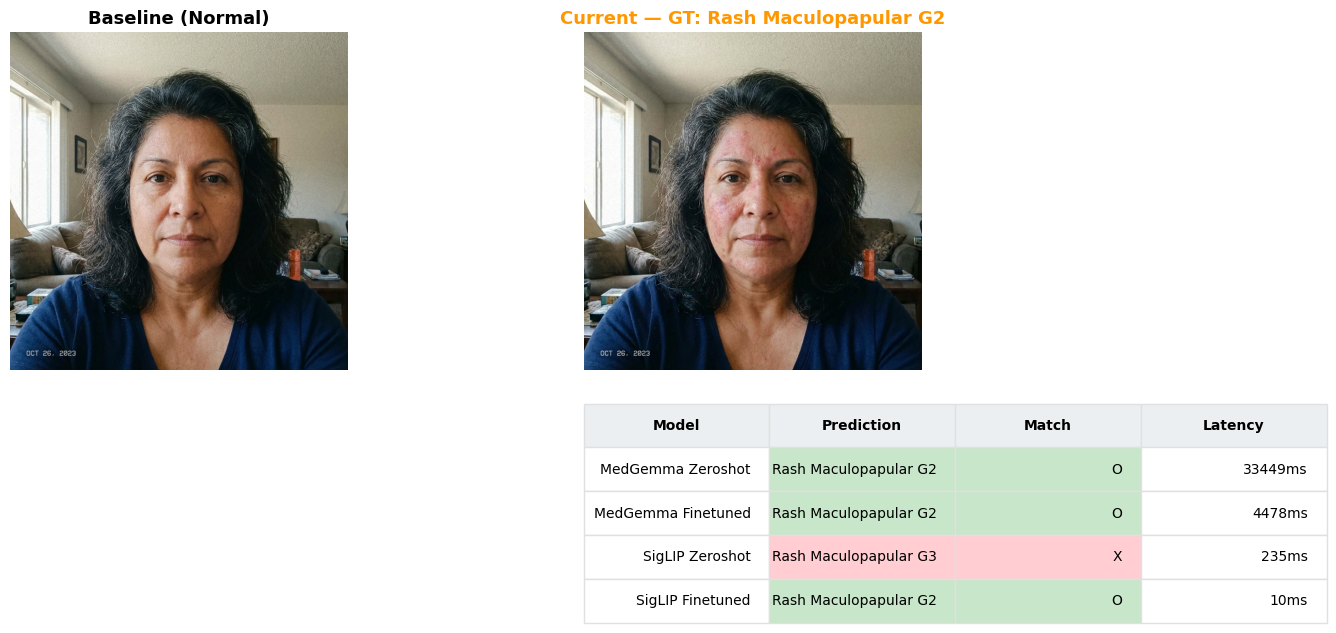

  [MedGemma Zeroshot] rash_maculopapular G2 — New onset of erythematous maculopapular rash on cheeks and forehead, more extensive and intense than in Image 1.
  [MedGemma Finetuned] rash_maculopapular G2 — Compared to baseline (Image 1), Image 2 shows Visible red macules/papules spreading across cheeks and forehead (10–30% B



In [8]:
_ = run_all_models("normal_8.png", "rash_maculopapular_g2_8.png", "rash_maculopapular_g2")

### 5-2. Normal (No Change)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Baseline: normal_9.png  |  Current: normal_9.png  |  GT: normal
--------------------------------------------------------------------------------


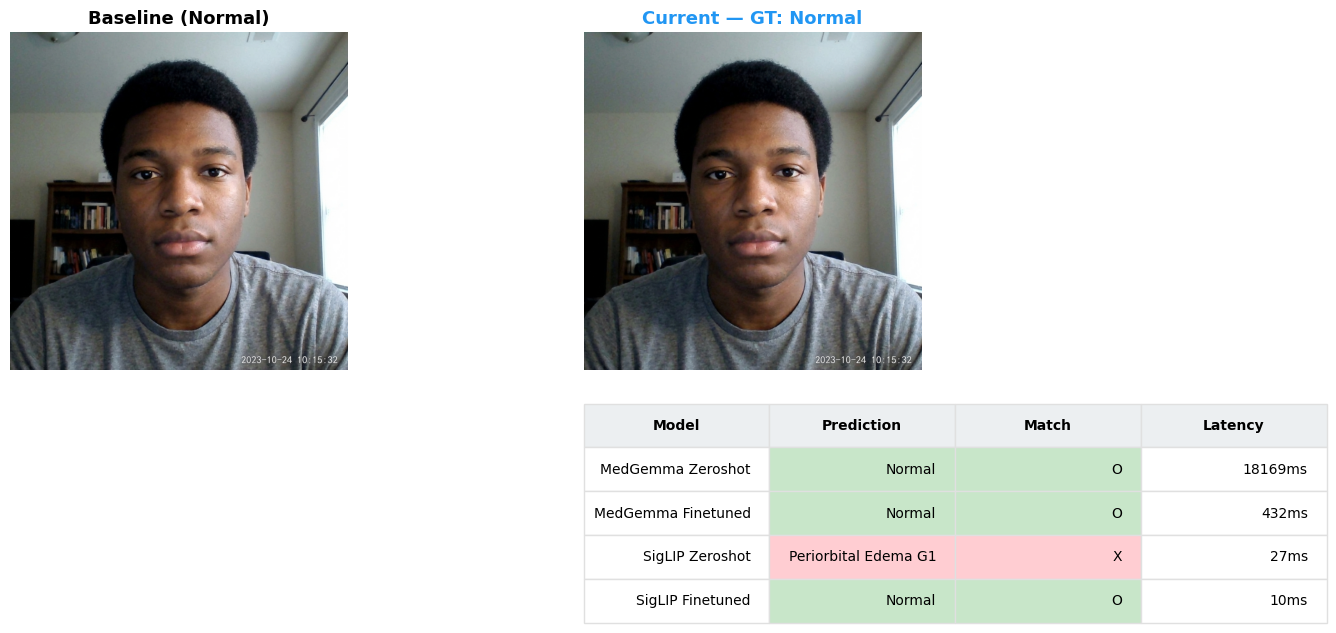

  [MedGemma Zeroshot] Normal — No AE detected
  [MedGemma Finetuned] Normal — No AE detected



In [9]:
_ = run_all_models("normal_9.png", "normal_9.png", "normal")

### 5-3. SJS Prodrome Grade 3 (Severe)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Baseline: normal_8.png  |  Current: sjs_prodrome_g3_8.png  |  GT: sjs_prodrome_g3
--------------------------------------------------------------------------------


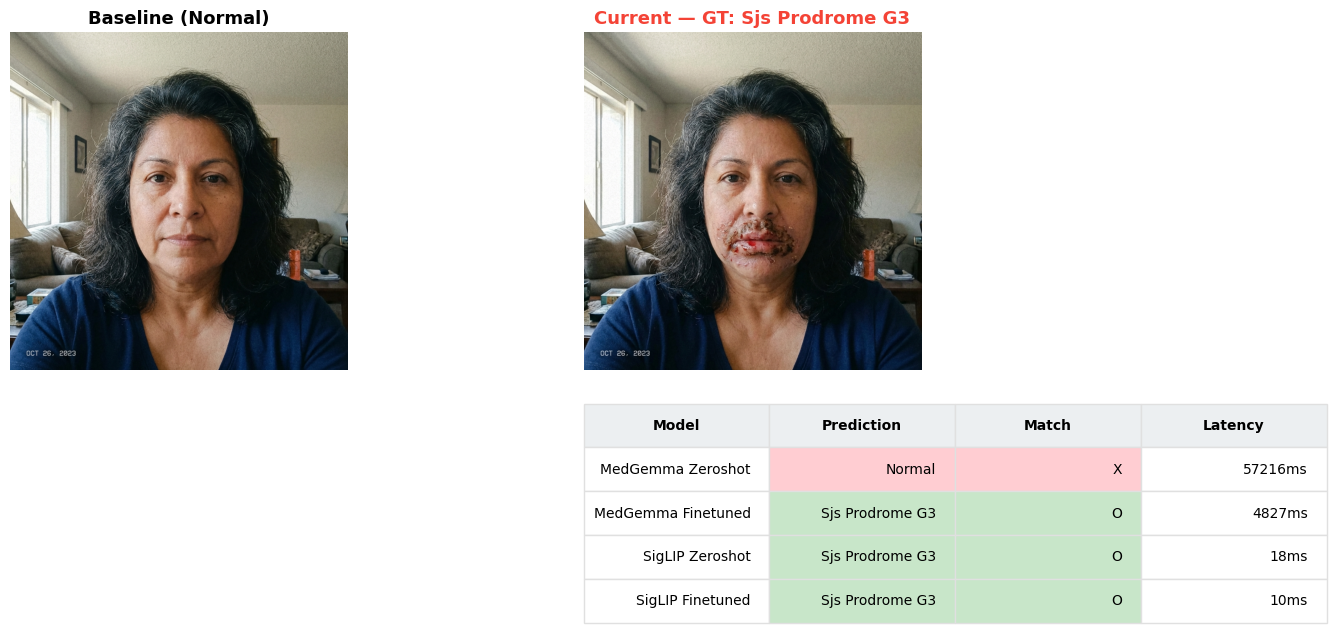

  [MedGemma Zeroshot] Normal — No AE detected
  [MedGemma Finetuned] sjs_prodrome G3 — Compared to baseline (Image 1), Image 2 shows Beginning of epidermal detachment on lips and perioral skin; large erosion



In [10]:
_ = run_all_models("normal_8.png", "sjs_prodrome_g3_8.png", "sjs_prodrome_g3")

### 5-4. Periorbital Edema Grade 1 (Mild)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Baseline: normal_8.png  |  Current: periorbital_edema_g1_8.png  |  GT: periorbital_edema_g1
--------------------------------------------------------------------------------


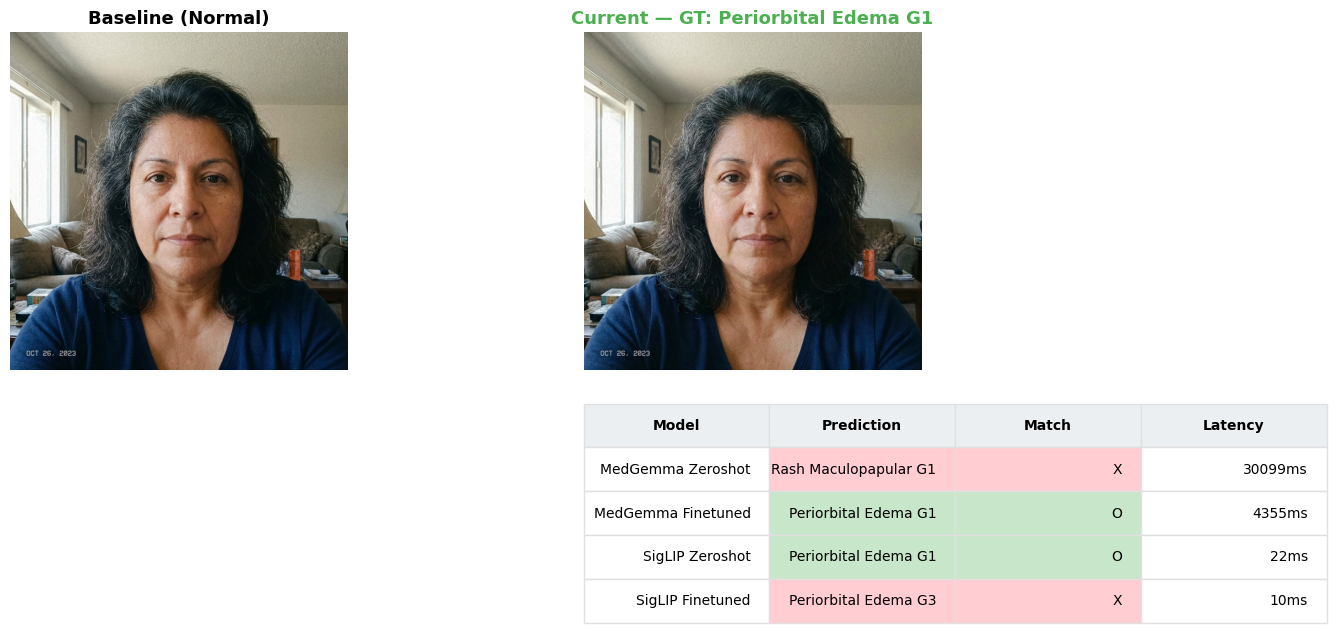

  [MedGemma Zeroshot] rash_maculopapular G1 — The patient has developed a mild maculopapular rash, characterized by small red spots, primarily on the cheeks and foreh
  [MedGemma Finetuned] periorbital_edema G1 — Compared to baseline (Image 1), Image 2 shows Slight puffiness of upper and lower eyelids, barely noticeable; periorbita



In [11]:
_ = run_all_models("normal_8.png", "periorbital_edema_g1_8.png", "periorbital_edema_g1")

### 5-5. Alopecia Grade 2

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Baseline: normal_9.png  |  Current: alopecia_g2_9.png  |  GT: alopecia_g2
--------------------------------------------------------------------------------


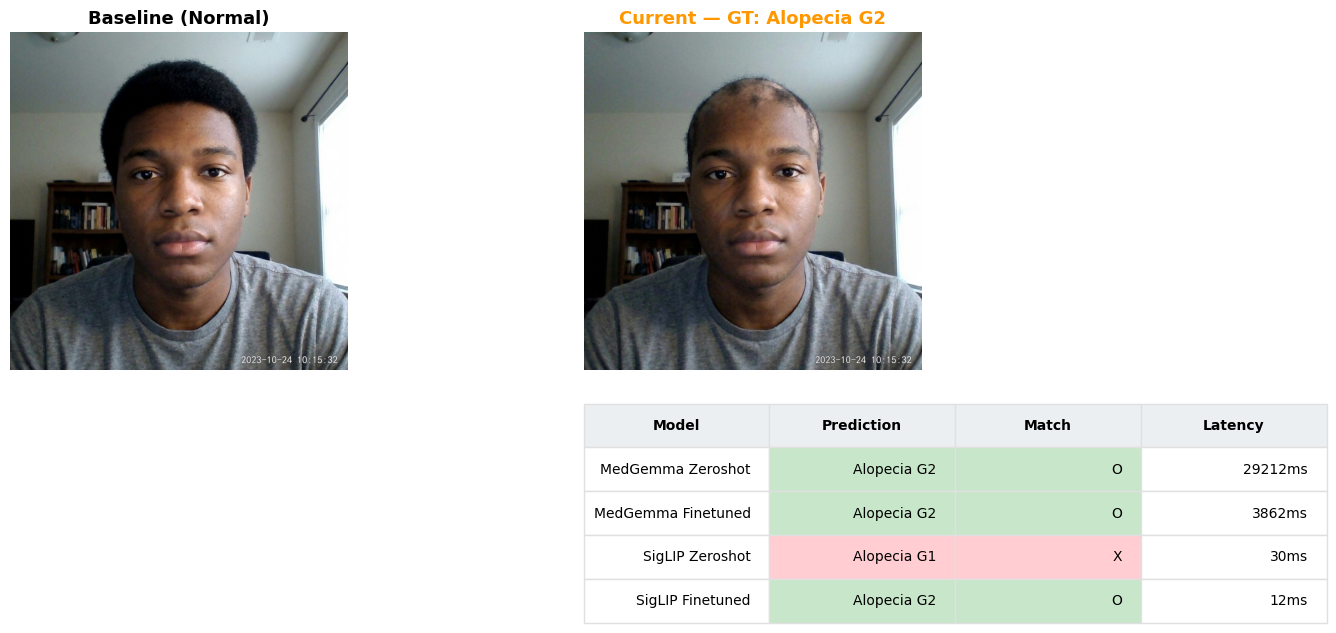

  [MedGemma Zeroshot] alopecia G2 — The patient's hair appears more thinned at the temples and frontal hairline in Image 2 compared to Image 1, with more sc
  [MedGemma Finetuned] alopecia G2 — Compared to baseline (Image 1), Image 2 shows Obvious diffuse hair thinning with clearly visible scalp through hair; tem



In [12]:
_ = run_all_models("normal_9.png", "alopecia_g2_9.png", "alopecia_g2")

## 6. Batch Test — Full Test Set Comparison

Run all 4 models on the full 42-image test set and compare Zeroshot vs Finetuned accuracy.

In [13]:
test_entries = [e for e in metadata["images"] if e["split"] == "test"]
print(f"Test entries: {len(test_entries)}")

all_results = []

for i, entry in enumerate(test_entries):
    pkey = f"{entry['profile']['age']}/{entry['profile']['sex']}/{entry['profile']['race']}"
    baseline_file = baseline_map.get(pkey)
    if not baseline_file:
        continue

    bp = IMAGE_DIR / baseline_file
    cp = IMAGE_DIR / entry["file"]
    gt = entry["class_name"]

    r_gz = predict_gemma(bp, cp, gemma_zeroshot, "GemmaZS")
    r_gf = predict_gemma(bp, cp, gemma_finetuned, "GemmaFT")
    r_sz = predict_siglip_zeroshot(cp)
    r_sf = predict_siglip_finetuned(cp)

    row = {
        "file": entry["file"], "gt": gt,
        "gemma_zs": r_gz["pred_class"], "gemma_ft": r_gf["pred_class"],
        "siglip_zs": r_sz["pred_class"], "siglip_ft": r_sf["pred_class"],
    }
    all_results.append(row)

    marks = "".join("O" if row[k] == gt else "X" for k in ["gemma_zs", "gemma_ft", "siglip_zs", "siglip_ft"])
    print(f"[{i+1:2d}/{len(test_entries)}] {marks}  gt={gt:<28} "
          f"GZ={r_gz['pred_class']:<24} GF={r_gf['pred_class']:<24} "
          f"SZ={r_sz['pred_class']:<24} SF={r_sf['pred_class']}")

# Summary
n = len(all_results)
print(f"\n{'Model':<22} {'Accuracy':>10} {'Correct':>10}")
print("-" * 45)
for key, label in [("gemma_zs", "MedGemma Zeroshot"), ("gemma_ft", "MedGemma Finetuned"),
                    ("siglip_zs", "SigLIP Zeroshot"), ("siglip_ft", "SigLIP Finetuned")]:
    correct = sum(1 for r in all_results if r[key] == r["gt"])
    print(f"{label:<22} {correct/n*100:>8.1f}%  {correct:>5}/{n}")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Test entries: 42


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[ 1/42] OOXO  gt=normal                       GZ=normal                   GF=normal                   SZ=periorbital_edema_g1     SF=normal


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[40/42] XOXO  gt=alopecia_g1                  GZ=normal                   GF=alopecia_g1              SZ=periorbital_edema_g1     SF=alopecia_g1


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[41/42] OOXO  gt=alopecia_g2                  GZ=alopecia_g2              GF=alopecia_g2              SZ=alopecia_g1              SF=alopecia_g2


[42/42] OOXO  gt=alopecia_g2                  GZ=alopecia_g2              GF=alopecia_g2              SZ=alopecia_g1              SF=alopecia_g2

Model                    Accuracy    Correct
---------------------------------------------
MedGemma Zeroshot          28.6%     12/42
MedGemma Finetuned         85.7%     36/42
SigLIP Zeroshot            28.6%     12/42
SigLIP Finetuned           61.9%     26/42


### 6-1. Accuracy Comparison (Zeroshot vs Finetuned)

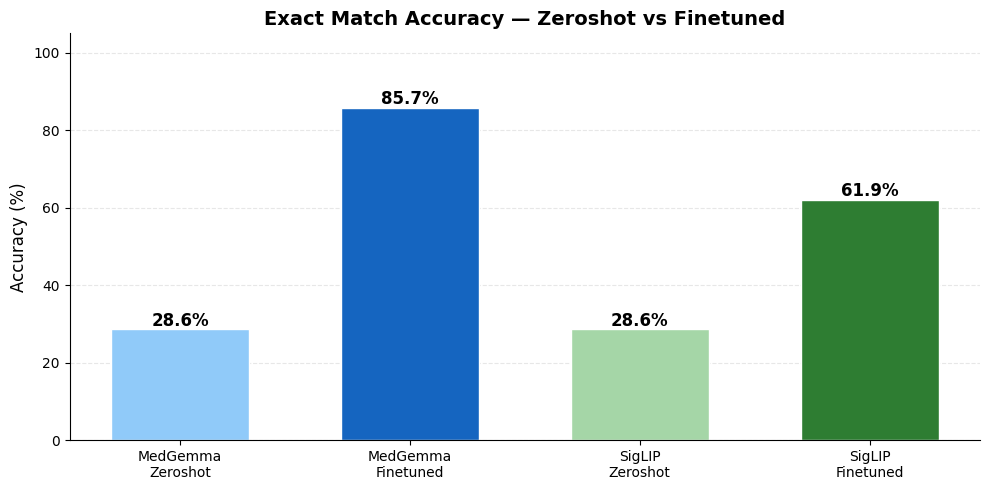

In [14]:
n = len(all_results)
models = {
    "MedGemma\nZeroshot": sum(1 for r in all_results if r["gemma_zs"] == r["gt"]) / n * 100,
    "MedGemma\nFinetuned": sum(1 for r in all_results if r["gemma_ft"] == r["gt"]) / n * 100,
    "SigLIP\nZeroshot": sum(1 for r in all_results if r["siglip_zs"] == r["gt"]) / n * 100,
    "SigLIP\nFinetuned": sum(1 for r in all_results if r["siglip_ft"] == r["gt"]) / n * 100,
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#90CAF9", "#1565C0", "#A5D6A7", "#2E7D32"]
bars = ax.bar(models.keys(), models.values(), color=colors, edgecolor="white", width=0.6)

for bar, val in zip(bars, models.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")

ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Exact Match Accuracy — Zeroshot vs Finetuned", fontsize=14, fontweight="bold")
ax.set_ylim(0, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 6-2. Per-AE-Type Detection Rate Comparison

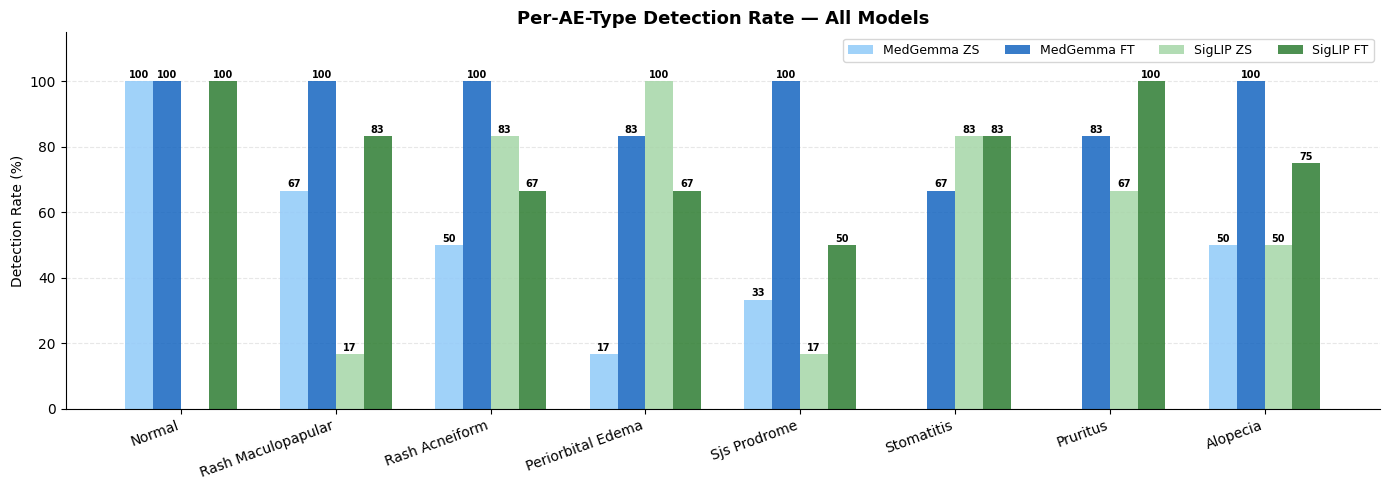

In [15]:
ae_types = ["normal", "rash_maculopapular", "rash_acneiform", "periorbital_edema",
            "sjs_prodrome", "stomatitis", "pruritus", "alopecia"]

model_keys = [("gemma_zs", "MedGemma ZS"), ("gemma_ft", "MedGemma FT"),
              ("siglip_zs", "SigLIP ZS"), ("siglip_ft", "SigLIP FT")]

# Compute per-AE detection rate for each model
ae_det_rates = {label: {} for _, label in model_keys}
for ae in ae_types:
    subset = [r for r in all_results if _parse_ae_type(r["gt"]) == ae]
    if not subset:
        continue
    for key, label in model_keys:
        detected = sum(1 for r in subset if _parse_ae_type(r[key]) == ae)
        ae_det_rates[label][ae] = detected / len(subset) * 100

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(ae_types))
width = 0.18
colors = ["#90CAF9", "#1565C0", "#A5D6A7", "#2E7D32"]

for idx, (_, label) in enumerate(model_keys):
    vals = [ae_det_rates[label].get(ae, 0) for ae in ae_types]
    offset = (idx - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=label, color=colors[idx], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                    f"{h:.0f}", ha="center", fontsize=7, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([ae.replace("_", " ").title() for ae in ae_types], rotation=20, ha="right")
ax.set_ylabel("Detection Rate (%)")
ax.set_title("Per-AE-Type Detection Rate — All Models", fontsize=13, fontweight="bold")
ax.set_ylim(0, 115)
ax.legend(ncol=4, fontsize=9, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 7. Custom Image Inference

You can specify external image paths directly to run comparative inference across all 4 models.

In [16]:
# baseline_image = "/path/to/your/baseline.png"
# current_image  = "/path/to/your/current.png"
# gt_label = "rash_maculopapular_g2"  # or "normal"
#
# _ = run_all_models(
#     Path(baseline_image).name, Path(current_image).name, gt_label
# )
#
# Or run individual models:
# r = predict_gemma(baseline_image, current_image, gemma_finetuned, "Finetuned")
# r = predict_siglip_finetuned(current_image)

---

# Part B — Cough Detection

**Model:** HeAR (Health Acoustic Representations) + 2-Stage Classifier

In [17]:
# ── Install dependencies (requires TensorFlow) ──
!pip install -q tensorflow tensorflow-hub librosa soundfile joblib scikit-learn numpy matplotlib huggingface-hub

# ── Install this project (for cough_detection imports) ──
!pip install -q -e ..

ERROR: file:///home/samuel does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [18]:
# [Original: kernel restart for TF GPU init]
# Replaced with explicit cleanup for nbconvert execution
import gc
import torch

# Delete all PyTorch models from Part A to free GPU memory
for _var in ['gemma_processor', 'gemma_zeroshot', 'gemma_finetuned',
             'siglip_processor', 'siglip_image_processor', 'siglip_model',
             'siglip_head']:
    if _var in dir():
        exec(f'del {_var}')

torch.cuda.empty_cache()
gc.collect()
print(f'GPU memory freed. Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')


GPU memory freed. Allocated: 0.01 GB


In [19]:
import os
import sys
import json
import warnings
from pathlib import Path
from collections import Counter
from huggingface_hub import snapshot_download

# === GPU setup — MUST happen before any TF import ===
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # ← change to your GPU index
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import tensorflow as tf
try:
    gpus = tf.config.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
except RuntimeError:
    pass
print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import IPython.display as ipd

warnings.filterwarnings('ignore')

SR = 16000

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

# Download dataset from HuggingFace
DATA_DIR = Path(snapshot_download("AlphaRaven/clinical-trial-engine-data", repo_type="dataset"))

print(f"ROOT: {ROOT}")
print(f"Data: {DATA_DIR}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ['CUDA_VISIBLE_DEVICES']}")

TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]


Fetching 247 files:   0%|          | 0/247 [00:00<?, ?it/s]

ROOT: /home/samuel/medgemma_ipynb
Data: /home/samuel/.cache/huggingface/hub/datasets--AlphaRaven--clinical-trial-engine-data/snapshots/dc4526af83a4722707ed993fda2149b4c94b4bb7
CUDA_VISIBLE_DEVICES: 0


## 1. Load Models

In [20]:
# --- 1a. HeAR model (PyTorch version) ---
from transformers import AutoModel
import torch

hear_model = AutoModel.from_pretrained("google/hear-pytorch").eval()
hear_device = torch.device("cpu")  # HeAR on CPU to save GPU for other models
hear_model = hear_model.to(hear_device)
print(f"HeAR-PyTorch loaded: {sum(p.numel() for p in hear_model.parameters())/1e6:.1f}M params")


HeAR-PyTorch loaded: 303.2M params


In [21]:
# --- 1b. Classifiers ---
import joblib
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

def _fix_sklearn_compat(clf):
    """Fix sklearn 1.8 -> 1.7 compat: restore removed multi_class attr."""
    if not hasattr(clf, 'multi_class'):
        clf.multi_class = 'auto'
    return clf

# Stage 1: 3-class (dry / wet / none)
model_dir_3c = DATA_DIR / "hear_mixed_model"
clf_3c = _fix_sklearn_compat(joblib.load(model_dir_3c / "classifier.joblib"))
le_3c  = joblib.load(model_dir_3c / "label_encoder.joblib")
print(f"Stage 1 (3-class): {le_3c.classes_}  \u2014 {type(clf_3c).__name__}")

# Stage 2: 2-class (dry / wet)
model_dir_2c = DATA_DIR / "hear_cough_only_model"
clf_2c = _fix_sklearn_compat(joblib.load(model_dir_2c / "classifier.joblib"))
le_2c  = joblib.load(model_dir_2c / "label_encoder.joblib")
print(f"Stage 2 (2-class): {le_2c.classes_}  \u2014 {type(clf_2c).__name__}")


Stage 1 (3-class): ['dry' 'none' 'wet']  — LogisticRegression
Stage 2 (2-class): ['dry' 'wet']  — RandomForestClassifier


In [22]:
# --- 1c. Segmentation function ---
from cough_detection.segmentation import segment_cough
print("segment_cough loaded from detect-segment-cough.")

segment_cough loaded from detect-segment-cough.


## 2. Select Audio File

In [23]:
# ========== CHANGE THIS PATH TO YOUR AUDIO FILE ==========
AUDIO_PATH = DATA_DIR / "cough_audio_samples" / "wet" / "wet_02_frequent_female.wav"
# ==========================================================

# Load audio
audio, sr = librosa.load(str(AUDIO_PATH), sr=SR)
duration = len(audio) / sr

print(f"File:     {AUDIO_PATH.name}")
print(f"Duration: {duration:.2f}s")
print(f"SR:       {sr} Hz")
print(f"Samples:  {len(audio):,}")

# Play audio
ipd.display(ipd.Audio(audio, rate=sr))

File:     wet_02_frequent_female.wav
Duration: 20.51s
SR:       16000 Hz
Samples:  328,206


In [24]:
# Load GT (if manifest exists)
manifest_path = AUDIO_PATH.parent.parent / "manifest.json"
gt_info = None
if manifest_path.exists():
    with open(manifest_path) as f:
        manifest = json.load(f)
    fname_key = f"{AUDIO_PATH.parent.name}/{AUDIO_PATH.name}"
    for s in manifest["samples"]:
        if s["filename"] == fname_key:
            gt_info = s
            break

if gt_info:
    print(f"GT Label:       {gt_info['label']}")
    print(f"Description:    {gt_info['description']}")
    print(f"Cough Inserted: {gt_info['cough_inserted']}")
    if gt_info.get("metadata", {}).get("cough_timestamps"):
        print(f"\nGT Cough Timestamps:")
        for ct in gt_info["metadata"]["cough_timestamps"]:
            print(f"  {ct['start_sec']:.3f}s ~ {ct['end_sec']:.3f}s  ({ct['duration_sec']:.1f}s, {ct['cough_type']})")
else:
    print("No manifest/GT found for this file.")

No manifest/GT found for this file.


## 3. Waveform & Spectrogram Visualization

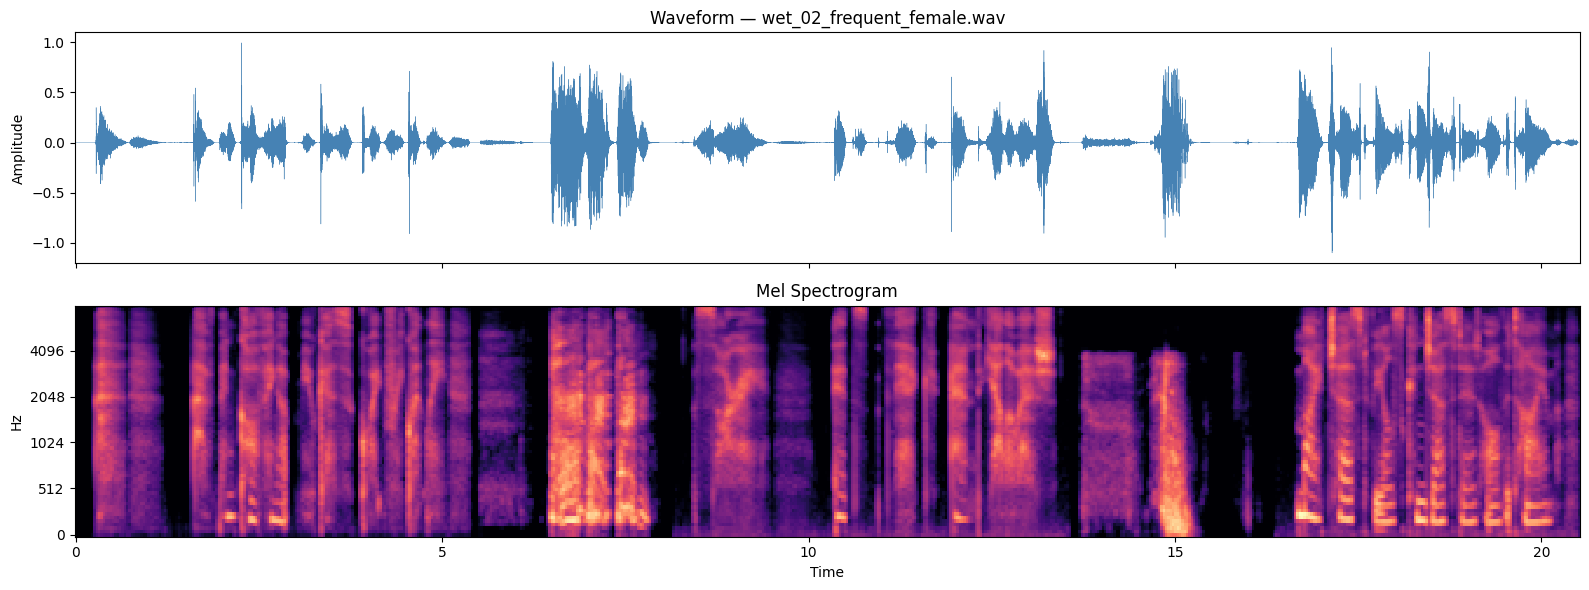

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
time_axis = np.arange(len(audio)) / sr

# Waveform
axes[0].plot(time_axis, audio, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Waveform — {AUDIO_PATH.name}')

# Mark GT cough regions
if gt_info and gt_info.get("metadata", {}).get("cough_timestamps"):
    for ct in gt_info["metadata"]["cough_timestamps"]:
        axes[0].axvspan(ct['start_sec'], ct['end_sec'], alpha=0.2, color='red', label='GT cough')
    # Deduplicate legend
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[0].legend(by_label.values(), by_label.keys(), loc='upper right')

# Spectrogram
S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=80, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
axes[1].set_title('Mel Spectrogram')

plt.tight_layout()
plt.show()

## 4. Energy-Based Segmentation (Step 1)

In [26]:
# Run energy-based hysteresis segmentation
segments, mask = segment_cough(audio, sr, cough_padding=0)

# Extract segment timestamps
changes = np.diff(mask.astype(int))
starts = np.where(changes == 1)[0] + 1
ends   = np.where(changes == -1)[0] + 1

# Energy thresholds (same as segmentation.py uses)
rms_global = np.sqrt(np.mean(np.square(audio)))
th_low  = 0.1 * rms_global
th_high = 2.0 * rms_global

print(f"Global RMS:    {rms_global:.4f}")
print(f"Threshold Low: {th_low:.4f}  (0.1 × RMS)")
print(f"Threshold High:{th_high:.4f}  (2.0 × RMS)")
print(f"Segments Found: {len(segments)}")
print()

# Segment table
print(f"{'Seg':>3}  {'Start':>7}  {'End':>7}  {'Dur':>6}  {'RMS':>7}  {'Samples':>8}")
print("-" * 50)
for i, (s, e) in enumerate(zip(starts, ends)):
    if i >= len(segments):
        break
    seg_rms = np.sqrt(np.mean(segments[i] ** 2))
    print(f"{i:>3}  {s/sr:>7.3f}  {e/sr:>7.3f}  {(e-s)/sr:>5.3f}s  {seg_rms:>7.4f}  {len(segments[i]):>8}")

Global RMS:    0.0874
Threshold Low: 0.0087  (0.1 × RMS)
Threshold High:0.1748  (2.0 × RMS)
Segments Found: 8

Seg    Start      End     Dur      RMS   Samples
--------------------------------------------------
  0    2.263    2.481  0.218s   0.1111      3490
  1    6.492    7.283  0.790s   0.2272     12646
  2    7.405    7.661  0.256s   0.2074      4102
  3   14.836   15.187  0.351s   0.2482      5616
  4   16.694   16.973  0.280s   0.2838      4475
  5   17.265   17.546  0.281s   0.1300      4498
  6   17.744   17.984  0.240s   0.1217      3841
  7   19.792   20.081  0.289s   0.0972      4623


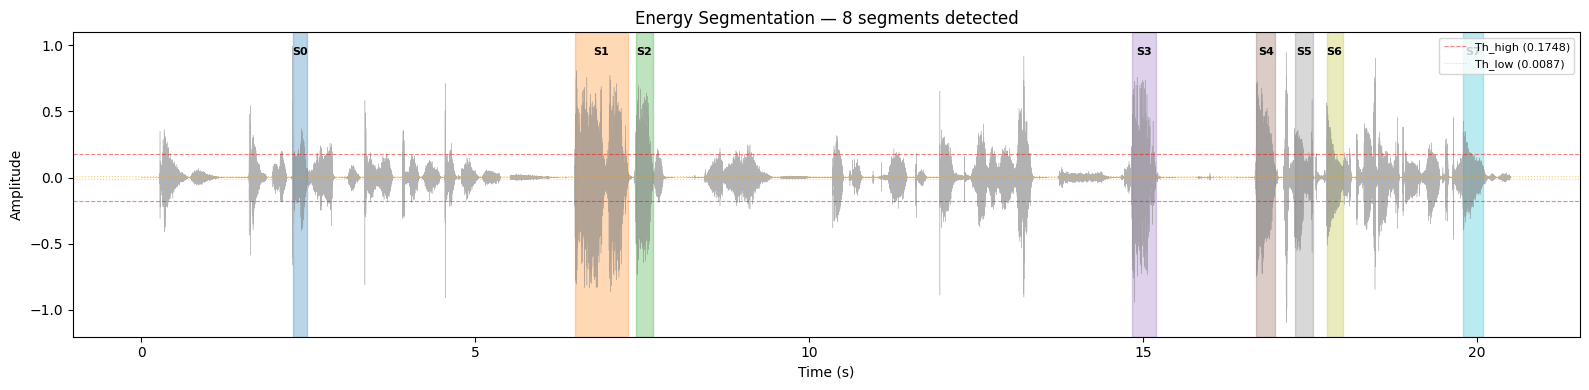

In [27]:
# Visualize segmentation on waveform
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(time_axis, audio, linewidth=0.3, color='gray', alpha=0.6)

# Highlight energy thresholds
ax.axhline(y=th_high, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label=f'Th_high ({th_high:.4f})')
ax.axhline(y=-th_high, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=th_low, color='orange', linestyle=':', linewidth=0.8, alpha=0.5, label=f'Th_low ({th_low:.4f})')
ax.axhline(y=-th_low, color='orange', linestyle=':', linewidth=0.8, alpha=0.5)

# Detected segments
colors = plt.cm.tab10(np.linspace(0, 1, max(len(starts), 1)))
for i, (s, e) in enumerate(zip(starts, ends)):
    if i >= len(segments):
        break
    ax.axvspan(s/sr, e/sr, alpha=0.3, color=colors[i % len(colors)])
    ax.text((s/sr + e/sr) / 2, ax.get_ylim()[1] * 0.9, f'S{i}',
            ha='center', va='top', fontsize=8, fontweight='bold')

# GT cough overlay
if gt_info and gt_info.get("metadata", {}).get("cough_timestamps"):
    for ct in gt_info["metadata"]["cough_timestamps"]:
        ax.axvspan(ct['start_sec'], ct['end_sec'], alpha=0.15, color='red',
                   ymin=0.0, ymax=0.1)
    ax.plot([], [], color='red', alpha=0.3, linewidth=8, label='GT cough region')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Energy Segmentation — {len(segments)} segments detected')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 5. HeAR Embedding Extraction (Step 2)

In [28]:
TARGET_LEN = 2 * SR  # 2 seconds = 32000 samples

def audio_to_mel(audio_segment, sr=SR, n_mels=128, n_fft=1024, hop_length=168, target_time=192):
    """Convert raw audio to mel spectrogram for HeAR-PyTorch (1, 192, 128)."""
    mel = librosa.feature.melspectrogram(y=audio_segment.astype(np.float32), sr=sr,
                                         n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    log_mel = librosa.power_to_db(mel, ref=np.max)  # (128, time)
    mel_t = log_mel.T  # (time, 128)
    if mel_t.shape[0] < target_time:
        mel_t = np.pad(mel_t, ((0, target_time - mel_t.shape[0]), (0, 0)))
    else:
        mel_t = mel_t[:target_time]
    return mel_t  # (192, 128)

def get_embedding(audio_segment):
    """Extract HeAR 512-d embedding from a 2-second audio segment (PyTorch)."""
    if len(audio_segment) < TARGET_LEN:
        padded = np.pad(audio_segment, (0, TARGET_LEN - len(audio_segment)))
    else:
        padded = audio_segment[:TARGET_LEN]
    mel = audio_to_mel(padded)
    with torch.no_grad():
        x = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(hear_device)
        out = hear_model(x, return_dict=True)
        emb = out.pooler_output.cpu().numpy()
    return emb

# Extract embeddings for all segments
embeddings = []
for i, seg in enumerate(segments):
    emb = get_embedding(seg)
    embeddings.append(emb)
    print(f"Seg {i}: {len(seg)} samples \u2192 embedding shape {emb.shape}, "
          f"norm={np.linalg.norm(emb):.2f}, mean={emb.mean():.4f}")

print(f"\nTotal: {len(embeddings)} embeddings extracted (512-d each)")


Seg 0: 3490 samples → embedding shape (1, 512), norm=260.15, mean=0.3132


Seg 1: 12646 samples → embedding shape (1, 512), norm=265.66, mean=0.3639


Seg 2: 4102 samples → embedding shape (1, 512), norm=267.06, mean=0.2647


Seg 3: 5616 samples → embedding shape (1, 512), norm=247.44, mean=0.2576


Seg 4: 4475 samples → embedding shape (1, 512), norm=264.79, mean=0.4038


Seg 5: 4498 samples → embedding shape (1, 512), norm=260.69, mean=0.3923


Seg 6: 3841 samples → embedding shape (1, 512), norm=268.71, mean=0.4350


Seg 7: 4623 samples → embedding shape (1, 512), norm=266.73, mean=0.3702

Total: 8 embeddings extracted (512-d each)


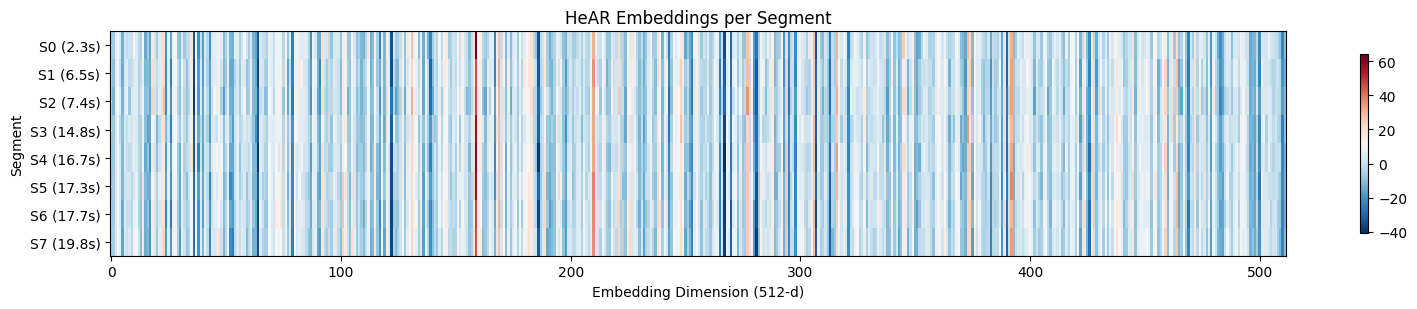

In [29]:
# Visualize embeddings as heatmap
if len(embeddings) > 0:
    emb_matrix = np.vstack(embeddings)
    fig, ax = plt.subplots(figsize=(16, max(2, len(embeddings) * 0.4)))
    im = ax.imshow(emb_matrix, aspect='auto', cmap='RdBu_r', interpolation='nearest')
    ax.set_xlabel('Embedding Dimension (512-d)')
    ax.set_ylabel('Segment')
    ax.set_yticks(range(len(embeddings)))
    ax.set_yticklabels([f'S{i} ({starts[i]/sr:.1f}s)' for i in range(len(embeddings))])
    ax.set_title('HeAR Embeddings per Segment')
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

## 6. Stage 1 — 3-Class Classification (dry / wet / none)

In [30]:
stage1_results = []

print(f"{'Seg':>3}  {'Time':>12}  {'Label':<6}  {'none':>6}  {'dry':>6}  {'wet':>6}")
print("-" * 55)

for i, emb in enumerate(embeddings):
    pred = clf_3c.predict(emb)[0]
    proba = clf_3c.predict_proba(emb)[0]
    label = le_3c.inverse_transform([pred])[0]
    prob_dict = {c: round(float(p), 3) for c, p in zip(le_3c.classes_, proba)}

    stage1_results.append({
        "index": i,
        "start": round(starts[i] / sr, 3),
        "end": round(ends[i] / sr, 3),
        "label": label,
        "probabilities": prob_dict,
    })

    marker = "<<" if label != "none" else ""
    print(f"{i:>3}  {starts[i]/sr:>5.2f}-{ends[i]/sr:<5.2f}s  {label:<6}  "
          f"{prob_dict.get('none',0):>6.1%}  {prob_dict.get('dry',0):>6.1%}  {prob_dict.get('wet',0):>6.1%}  {marker}")

n_cough = sum(1 for r in stage1_results if r['label'] != 'none')
n_none  = sum(1 for r in stage1_results if r['label'] == 'none')
print(f"\nSummary: {n_cough} cough segments, {n_none} non-cough segments")

Seg          Time  Label     none     dry     wet
-------------------------------------------------------
  0   2.26-2.48 s  none    100.0%    0.0%    0.0%  
  1   6.49-7.28 s  none    100.0%    0.0%    0.0%  
  2   7.40-7.66 s  none    100.0%    0.0%    0.0%  
  3  14.84-15.19s  none    100.0%    0.0%    0.0%  
  4  16.69-16.97s  none    100.0%    0.0%    0.0%  
  5  17.26-17.55s  none    100.0%    0.0%    0.0%  
  6  17.74-17.98s  none    100.0%    0.0%    0.0%  
  7  19.79-20.08s  none    100.0%    0.0%    0.0%  

Summary: 0 cough segments, 8 non-cough segments


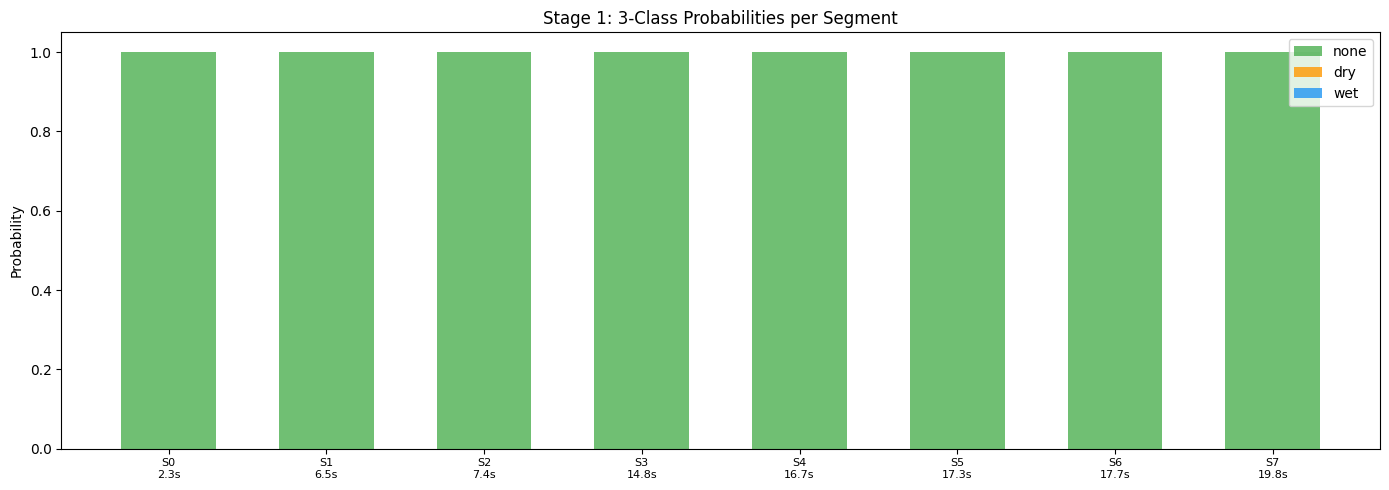

In [31]:
# Visualize Stage 1 probabilities
if len(stage1_results) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))

    seg_indices = range(len(stage1_results))
    none_probs = [r['probabilities'].get('none', 0) for r in stage1_results]
    dry_probs  = [r['probabilities'].get('dry', 0) for r in stage1_results]
    wet_probs  = [r['probabilities'].get('wet', 0) for r in stage1_results]

    bar_width = 0.6
    ax.bar(seg_indices, none_probs, bar_width, label='none', color='#4CAF50', alpha=0.8)
    ax.bar(seg_indices, dry_probs, bar_width, bottom=none_probs, label='dry', color='#FF9800', alpha=0.8)
    ax.bar(seg_indices, wet_probs, bar_width,
           bottom=[n + d for n, d in zip(none_probs, dry_probs)], label='wet', color='#2196F3', alpha=0.8)

    ax.set_xticks(seg_indices)
    ax.set_xticklabels([f'S{r["index"]}\n{r["start"]:.1f}s' for r in stage1_results], fontsize=8)
    ax.set_ylabel('Probability')
    ax.set_title('Stage 1: 3-Class Probabilities per Segment')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1.05)

    # Mark cough segments
    for i, r in enumerate(stage1_results):
        if r['label'] != 'none':
            ax.annotate(r['label'], (i, 1.02), ha='center', fontsize=8, fontweight='bold', color='red')

    plt.tight_layout()
    plt.show()

## 7. Stage 2 — 2-Class Re-classification (dry / wet)

In [32]:
stage2_results = []

print("Only cough segments from Stage 1 are re-classified:")
print(f"{'Seg':>3}  {'Time':>12}  {'S1 Label':<9}  {'S2 Label':<9}  {'dry':>6}  {'wet':>6}  {'Final none':>10}  {'Final dry':>10}  {'Final wet':>10}")
print("-" * 95)

for i, (emb, s1) in enumerate(zip(embeddings, stage1_results)):
    if s1['label'] == 'none':
        # Pass through as-is
        stage2_results.append({
            **s1,
            "stage": "1-none",
            "final_label": "none",
            "final_probs": s1['probabilities'],
        })
        print(f"{i:>3}  {s1['start']:>5.2f}-{s1['end']:<5.2f}s  {'none':<9}  {'—':<9}  {'—':>6}  {'—':>6}  "
              f"{s1['probabilities'].get('none',0):>10.1%}  {s1['probabilities'].get('dry',0):>10.1%}  {s1['probabilities'].get('wet',0):>10.1%}")
    else:
        # Stage 2 re-classification
        pred_2c = clf_2c.predict(emb)[0]
        proba_2c = clf_2c.predict_proba(emb)[0]
        label_2c = le_2c.inverse_transform([pred_2c])[0]
        prob_2c = {c: round(float(p), 3) for c, p in zip(le_2c.classes_, proba_2c)}

        # Merge: none from Stage1, dry/wet from Stage2 scaled by cough probability
        none_prob = s1['probabilities'].get('none', 0.0)
        cough_prob = 1.0 - none_prob
        final_probs = {
            'none': none_prob,
            'dry': round(cough_prob * prob_2c.get('dry', 0.0), 3),
            'wet': round(cough_prob * prob_2c.get('wet', 0.0), 3),
        }

        stage2_results.append({
            **s1,
            "stage": "2-cough",
            "stage2_label": label_2c,
            "stage2_probs": prob_2c,
            "final_label": label_2c,
            "final_probs": final_probs,
        })
        print(f"{i:>3}  {s1['start']:>5.2f}-{s1['end']:<5.2f}s  {s1['label']:<9}  {label_2c:<9}  "
              f"{prob_2c.get('dry',0):>6.1%}  {prob_2c.get('wet',0):>6.1%}  "
              f"{final_probs['none']:>10.1%}  {final_probs['dry']:>10.1%}  {final_probs['wet']:>10.1%}")

Only cough segments from Stage 1 are re-classified:
Seg          Time  S1 Label   S2 Label      dry     wet  Final none   Final dry   Final wet
-----------------------------------------------------------------------------------------------
  0   2.26-2.48 s  none       —               —       —      100.0%        0.0%        0.0%
  1   6.49-7.28 s  none       —               —       —      100.0%        0.0%        0.0%
  2   7.41-7.66 s  none       —               —       —      100.0%        0.0%        0.0%
  3  14.84-15.19s  none       —               —       —      100.0%        0.0%        0.0%
  4  16.69-16.97s  none       —               —       —      100.0%        0.0%        0.0%
  5  17.27-17.55s  none       —               —       —      100.0%        0.0%        0.0%
  6  17.74-17.98s  none       —               —       —      100.0%        0.0%        0.0%
  7  19.79-20.08s  none       —               —       —      100.0%        0.0%        0.0%


In [33]:
# Visualize Stage 2 — only cough segments
cough_s2 = [r for r in stage2_results if r['stage'] == '2-cough']

if cough_s2:
    fig, ax = plt.subplots(figsize=(max(6, len(cough_s2) * 1.5), 4))

    x_pos = range(len(cough_s2))
    dry_vals = [r['stage2_probs']['dry'] for r in cough_s2]
    wet_vals = [r['stage2_probs']['wet'] for r in cough_s2]

    bar_w = 0.35
    ax.bar([x - bar_w/2 for x in x_pos], dry_vals, bar_w, label='dry', color='#FF9800')
    ax.bar([x + bar_w/2 for x in x_pos], wet_vals, bar_w, label='wet', color='#2196F3')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"S{r['index']}\n{r['start']:.1f}s" for r in cough_s2], fontsize=9)
    ax.set_ylabel('Probability')
    ax.set_title('Stage 2: dry vs wet Re-classification (cough segments only)')
    ax.legend()
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylim(0, 1.05)

    for i, r in enumerate(cough_s2):
        winner = r['final_label']
        ax.annotate(winner, (i, max(dry_vals[i], wet_vals[i]) + 0.03),
                    ha='center', fontsize=9, fontweight='bold',
                    color='#FF9800' if winner == 'dry' else '#2196F3')

    plt.tight_layout()
    plt.show()
else:
    print("No cough segments detected — Stage 2 skipped.")

No cough segments detected — Stage 2 skipped.


## 8. Final Prediction (Majority Vote)

In [34]:
# Majority vote among cough segments
cough_labels = [r['final_label'] for r in stage2_results if r['final_label'] in ('dry', 'wet')]

if cough_labels:
    vote_counts = Counter(cough_labels)
    predicted = vote_counts.most_common(1)[0][0]
    print("Cough segment votes:")
    for label, count in vote_counts.most_common():
        pct = count / len(cough_labels) * 100
        bar = '#' * (count * 4)
        print(f"  {label:<5}: {count} ({pct:.0f}%)  {bar}")
else:
    predicted = "none"
    print("No cough segments detected.")

gt_label = gt_info['label'] if gt_info else '?'
correct = predicted == gt_label

print(f"\n{'='*40}")
print(f"  Ground Truth:  {gt_label}")
print(f"  Prediction:    {predicted}")
print(f"  Result:        {'CORRECT' if correct else 'WRONG'}")
print(f"{'='*40}")

No cough segments detected.

  Ground Truth:  ?
  Prediction:    none
  Result:        WRONG


## 9. Full Timeline Visualization

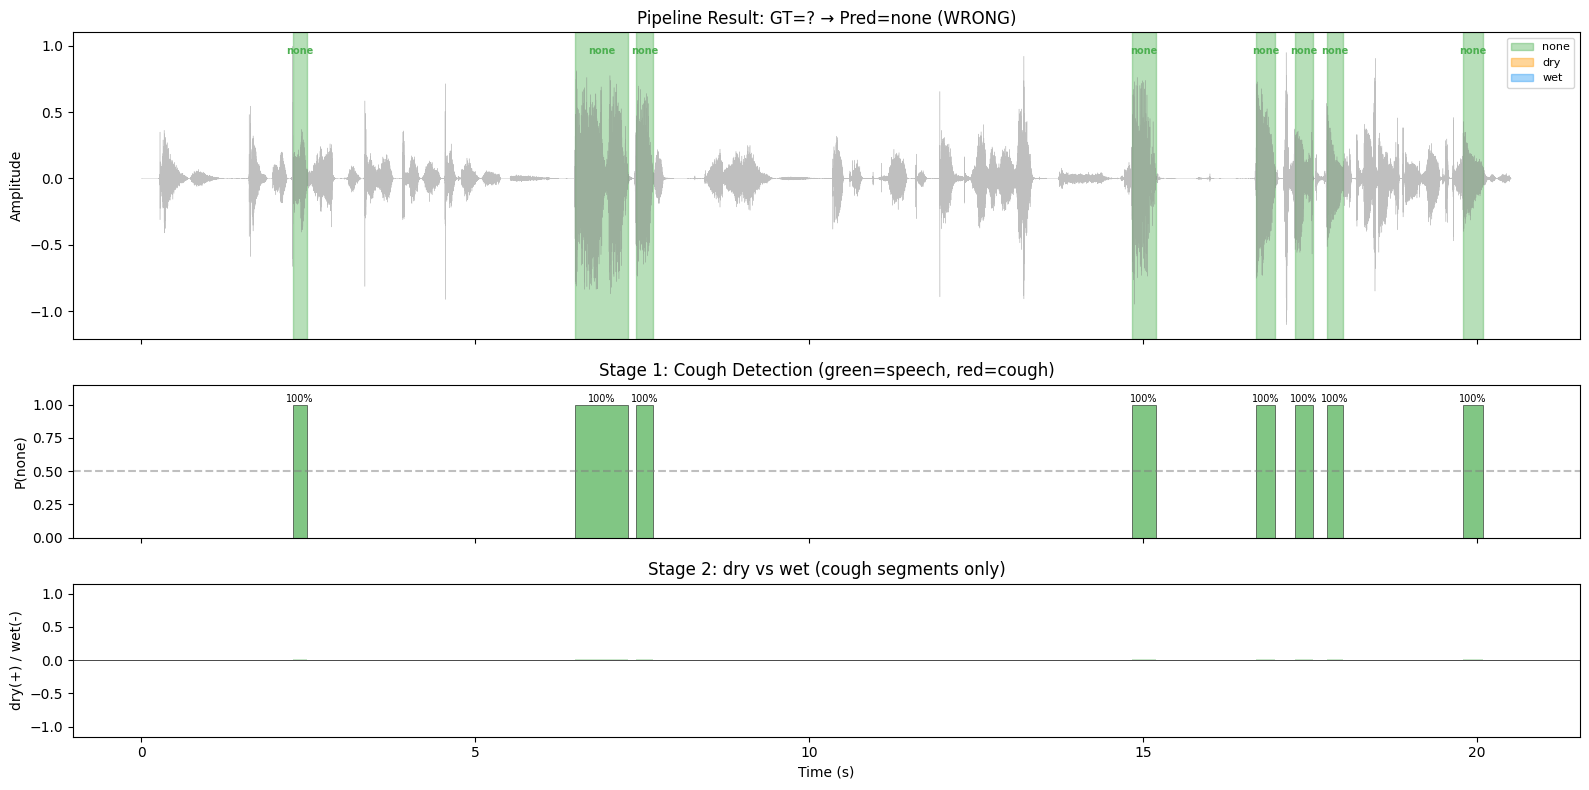

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1, 1]})

# --- Top: Waveform + segments + GT ---
ax = axes[0]
ax.plot(time_axis, audio, linewidth=0.3, color='gray', alpha=0.5)

color_map = {'none': '#4CAF50', 'dry': '#FF9800', 'wet': '#2196F3'}

for r in stage2_results:
    c = color_map.get(r['final_label'], 'gray')
    ax.axvspan(r['start'], r['end'], alpha=0.4, color=c)
    ax.text((r['start'] + r['end']) / 2, ax.get_ylim()[1] * 0.85,
            f"{r['final_label']}", ha='center', fontsize=7, fontweight='bold', color=c)

if gt_info and gt_info.get("metadata", {}).get("cough_timestamps"):
    for ct in gt_info["metadata"]["cough_timestamps"]:
        ax.axvspan(ct['start_sec'], ct['end_sec'], alpha=0.1, color='red', ymin=0, ymax=0.15)
        ax.text((ct['start_sec'] + ct['end_sec'])/2, ax.get_ylim()[0] * 0.9,
                f"GT:{ct['cough_type']}", ha='center', fontsize=7, color='red')

patches = [mpatches.Patch(color=c, alpha=0.4, label=l) for l, c in color_map.items()]
if gt_info and gt_info.get("metadata", {}).get("cough_timestamps"):
    patches.append(mpatches.Patch(color='red', alpha=0.15, label='GT cough'))
ax.legend(handles=patches, loc='upper right', fontsize=8)
ax.set_ylabel('Amplitude')
ax.set_title(f'Pipeline Result: GT={gt_label} → Pred={predicted} ({"CORRECT" if correct else "WRONG"})')

# --- Middle: Stage 1 none probability ---
ax = axes[1]
for r in stage2_results:
    mid = (r['start'] + r['end']) / 2
    w = r['end'] - r['start']
    none_p = r['final_probs'].get('none', 0)
    c = '#4CAF50' if none_p > 0.5 else '#E53935'
    ax.bar(mid, none_p, width=w, color=c, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.text(mid, none_p + 0.02, f'{none_p:.0%}', ha='center', fontsize=7)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('P(none)')
ax.set_ylim(0, 1.15)
ax.set_title('Stage 1: Cough Detection (green=speech, red=cough)')

# --- Bottom: Stage 2 dry/wet split ---
ax = axes[2]
for r in stage2_results:
    mid = (r['start'] + r['end']) / 2
    w = r['end'] - r['start']
    if r['stage'] == '2-cough':
        dry_p = r['stage2_probs']['dry']
        wet_p = r['stage2_probs']['wet']
        ax.bar(mid, dry_p, width=w, color='#FF9800', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.bar(mid, -wet_p, width=w, color='#2196F3', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.text(mid, dry_p + 0.03, f'd:{dry_p:.0%}', ha='center', fontsize=7, color='#E65100')
        ax.text(mid, -wet_p - 0.08, f'w:{wet_p:.0%}', ha='center', fontsize=7, color='#0D47A1')
    else:
        ax.bar(mid, 0.02, width=w, color='#4CAF50', alpha=0.3)

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('dry(+) / wet(-)')
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel('Time (s)')
ax.set_title('Stage 2: dry vs wet (cough segments only)')

plt.tight_layout()
plt.show()

## 10. Listen to Individual Segments

In [36]:
# Play each segment with its classification
for i, (seg, r) in enumerate(zip(segments, stage2_results)):
    label = r['final_label']
    probs = r['final_probs']
    prob_str = "  ".join(f"{k}={v:.1%}" for k, v in probs.items())

    icon = {"none": "[speech]", "dry": "[DRY cough]", "wet": "[WET cough]"}.get(label, "")
    print(f"\nSegment {i} ({r['start']:.2f}s ~ {r['end']:.2f}s) — {icon} {label}")
    print(f"  {prob_str}")
    ipd.display(ipd.Audio(seg, rate=sr))


Segment 0 (2.26s ~ 2.48s) — [speech] none
  dry=0.0%  none=100.0%  wet=0.0%



Segment 1 (6.49s ~ 7.28s) — [speech] none
  dry=0.0%  none=100.0%  wet=0.0%



Segment 2 (7.41s ~ 7.66s) — [speech] none
  dry=0.0%  none=100.0%  wet=0.0%



Segment 3 (14.84s ~ 15.19s) — [speech] none
  dry=0.0%  none=100.0%  wet=0.0%



Segment 4 (16.69s ~ 16.97s) — [speech] none
  dry=0.0%  none=100.0%  wet=0.0%



Segment 5 (17.27s ~ 17.55s) — [speech] none
  dry=0.0%  none=100.0%  wet=0.0%



Segment 6 (17.74s ~ 17.98s) — [speech] none
  dry=0.0%  none=100.0%  wet=0.0%



Segment 7 (19.79s ~ 20.08s) — [speech] none
  dry=0.0%  none=100.0%  wet=0.0%


## 11. Batch Test (All v4 samples)

In [37]:
def run_pipeline_single(audio_path):
    """Run full 2-stage pipeline on a single file. Returns result dict."""
    audio_raw, sr_raw = librosa.load(str(audio_path), sr=SR)
    segs, msk = segment_cough(audio_raw, sr_raw, cough_padding=0)
    ch = np.diff(msk.astype(int))
    ss = np.where(ch == 1)[0] + 1
    ee = np.where(ch == -1)[0] + 1

    seg_results = []
    for j, (s, e) in enumerate(zip(ss, ee)):
        if j >= len(segs):
            break
        emb = get_embedding(segs[j])

        # Stage 1
        pred_3c = clf_3c.predict(emb)[0]
        proba_3c = clf_3c.predict_proba(emb)[0]
        label_3c = le_3c.inverse_transform([pred_3c])[0]
        prob_3c = {c: round(float(p), 3) for c, p in zip(le_3c.classes_, proba_3c)}

        if label_3c == 'none':
            final_label = 'none'
            final_probs = prob_3c
        else:
            # Stage 2
            pred_2c = clf_2c.predict(emb)[0]
            proba_2c = clf_2c.predict_proba(emb)[0]
            label_2c = le_2c.inverse_transform([pred_2c])[0]
            prob_2c = {c: round(float(p), 3) for c, p in zip(le_2c.classes_, proba_2c)}
            none_p = prob_3c.get('none', 0)
            cough_p = 1.0 - none_p
            final_label = label_2c
            final_probs = {
                'none': none_p,
                'dry': round(cough_p * prob_2c.get('dry', 0), 3),
                'wet': round(cough_p * prob_2c.get('wet', 0), 3),
            }

        seg_results.append({
            'start': round(s / sr_raw, 3),
            'end': round(e / sr_raw, 3),
            'label': final_label,
            'probs': final_probs,
        })

    # Majority vote
    cough_labels = [r['label'] for r in seg_results if r['label'] in ('dry', 'wet')]
    if cough_labels:
        predicted = Counter(cough_labels).most_common(1)[0][0]
    else:
        predicted = 'none'

    return {
        'predicted': predicted,
        'n_segments': len(seg_results),
        'n_cough': len(cough_labels),
        'vote_counts': dict(Counter(cough_labels)) if cough_labels else {},
        'segments': seg_results,
    }

In [38]:
# Run batch test on all v4 samples
input_dir = DATA_DIR / "cough_audio_samples"

files = []
for label in ("dry", "wet", "none"):
    label_dir = input_dir / label
    if label_dir.exists():
        for wav in sorted(label_dir.glob("*.wav")):
            files.append((wav, label))

print(f"Testing {len(files)} files...\n")
print(f"{'File':<40} {'GT':<6} {'Pred':<6} {'OK':<4} {'Segs':>4} {'Cough':>5} {'Votes'}")
print("-" * 90)

correct_count = 0
batch_results = []

for wav_path, gt in files:
    r = run_pipeline_single(wav_path)
    ok = r['predicted'] == gt
    if ok:
        correct_count += 1
    
    vote_str = ", ".join(f"{k}:{v}" for k, v in r['vote_counts'].items()) if r['vote_counts'] else "-"
    mark = 'O' if ok else 'X'
    print(f"{wav_path.name:<40} {gt:<6} {r['predicted']:<6} {mark:<4} {r['n_segments']:>4} {r['n_cough']:>5} {vote_str}")
    batch_results.append({**r, 'file': wav_path.name, 'gt': gt, 'correct': ok})

print(f"\nAccuracy: {correct_count}/{len(files)} ({correct_count/len(files)*100:.1f}%)")

Testing 6 files...

File                                     GT     Pred   OK   Segs Cough Votes
------------------------------------------------------------------------------------------


dry_02_frequent_male.wav                 dry    none   X       6     0 -


dry_04_occasional_middle_female.wav      dry    none   X      10     0 -


wet_01_occasional_male.wav               wet    none   X       9     0 -


wet_02_frequent_female.wav               wet    none   X       8     0 -


none_01_healthy_young_male.wav           none   none   O       4     0 -


none_03_anxious_middle_male.wav          none   none   O       3     0 -

Accuracy: 2/6 (33.3%)


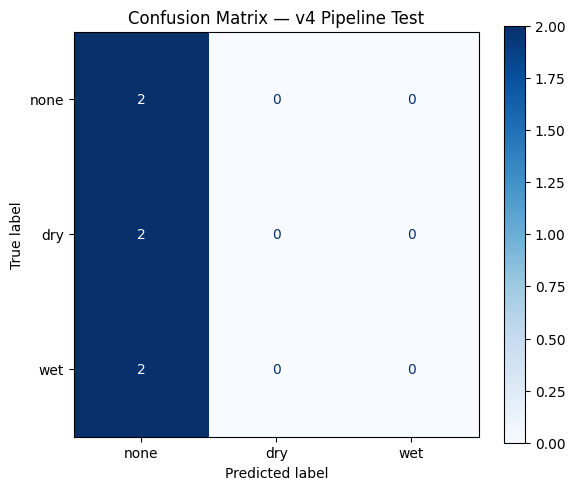

In [39]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

gt_labels = [r['gt'] for r in batch_results]
pred_labels = [r['predicted'] for r in batch_results]
labels = ['none', 'dry', 'wet']

cm = confusion_matrix(gt_labels, pred_labels, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — v4 Pipeline Test')
plt.tight_layout()
plt.show()